<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-17-Gradient_Boosting_Regressor(Scratch_algo).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

# Create input feature
X = np.linspace(0, 10, 120).reshape(-1, 1)

# Create nonlinear target
y = 2 * X.ravel() + 8 * np.sin(X.ravel()) + np.random.normal(0, 1.5, 120)

# Create DataFrame
df = pd.DataFrame({
    "X": X.ravel(),
    "y": y
})

df.head()

,X,y
0,0.000000,0.745071
1,0.084034,0.632149
2,0.168067,2.645884
3,0.252101,4.784258
4,0.336134,2.959762


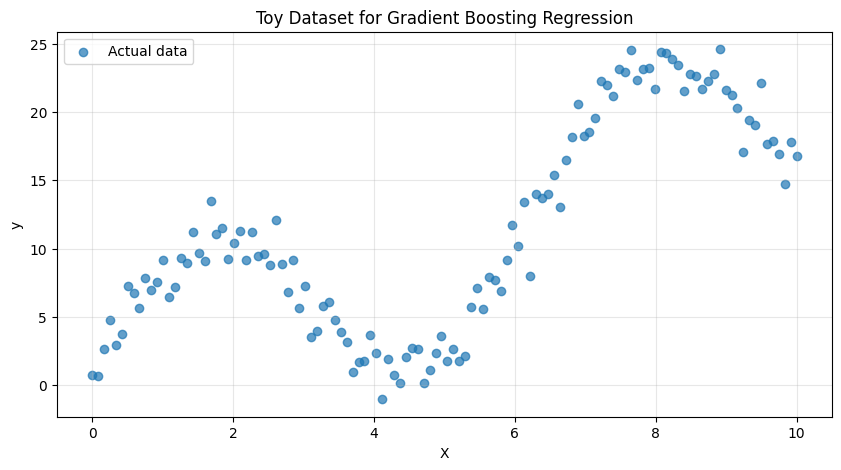

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(df["X"], df["y"], alpha=0.7, label="Actual data")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Toy Dataset for Gradient Boosting Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
class GradientBoostingRegressionScratch:

    def __init__(self, n_estimators=10, max_depth=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth

        self.trees = []
        self.gammas = []
        self.initial_prediction = None

        # Store model predictions at every stage
        self.stage_predictions = []

    def fit(self, X, y):

        # -----------------------------------
        # Step 1: Initialize f₀(x)
        # -----------------------------------
        self.initial_prediction = np.mean(y)

        # Initial prediction for every sample
        current_prediction = np.full(
            shape=len(y),
            fill_value=self.initial_prediction,
            dtype=float
        )

        self.stage_predictions.append(current_prediction.copy())

        # -----------------------------------
        # Step 2: Repeat for M iterations
        # -----------------------------------
        for m in range(self.n_estimators):

            # -----------------------------------
            # (a) Calculate negative gradient
            # For MSE: residual = y - prediction
            # -----------------------------------
            residuals = y - current_prediction

            # -----------------------------------
            # (b) Fit regression tree to residuals
            # -----------------------------------
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=42
            )

            tree.fit(X, residuals)

            # -----------------------------------
            # (c) Calculate gamma for every leaf
            # gamma = mean residual in that leaf
            # -----------------------------------
            leaf_ids = tree.apply(X)

            leaf_gamma = {}

            for leaf_id in np.unique(leaf_ids):

                # Select residuals belonging to this leaf
                residuals_in_leaf = residuals[leaf_ids == leaf_id]

                # Optimal gamma for squared loss
                gamma = np.mean(residuals_in_leaf)

                leaf_gamma[leaf_id] = gamma

            # -----------------------------------
            # (d) Update model additively
            # -----------------------------------
            tree_contribution = np.array([
                leaf_gamma[leaf_id]
                for leaf_id in leaf_ids
            ])

            current_prediction = current_prediction + tree_contribution

            # Save everything
            self.trees.append(tree)
            self.gammas.append(leaf_gamma)
            self.stage_predictions.append(current_prediction.copy())

        return self

    def predict(self, X):

        # Start with f₀(x)
        predictions = np.full(
            shape=X.shape[0],
            fill_value=self.initial_prediction,
            dtype=float
        )

        # Add contribution from every tree
        for tree, leaf_gamma in zip(self.trees, self.gammas):

            leaf_ids = tree.apply(X)

            tree_contribution = np.array([
                leaf_gamma[leaf_id]
                for leaf_id in leaf_ids
            ])

            predictions = predictions + tree_contribution

        return predictions

In [ ]:
# Create and train model
gb_model = GradientBoostingRegressionScratch(
    n_estimators=20,
    max_depth=1
)

gb_model.fit(X, y)

# Predictions
y_pred = gb_model.predict(X)

print("Initial prediction f₀(x):", gb_model.initial_prediction)
print("Number of trees:", len(gb_model.trees))

Initial prediction f₀(x): 11.321250448909616
Number of trees: 20


In [ ]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 2.8970051375114876
R² Score: 0.9507400328701713


# 7. Plot the final Gradient Boosting model 📈

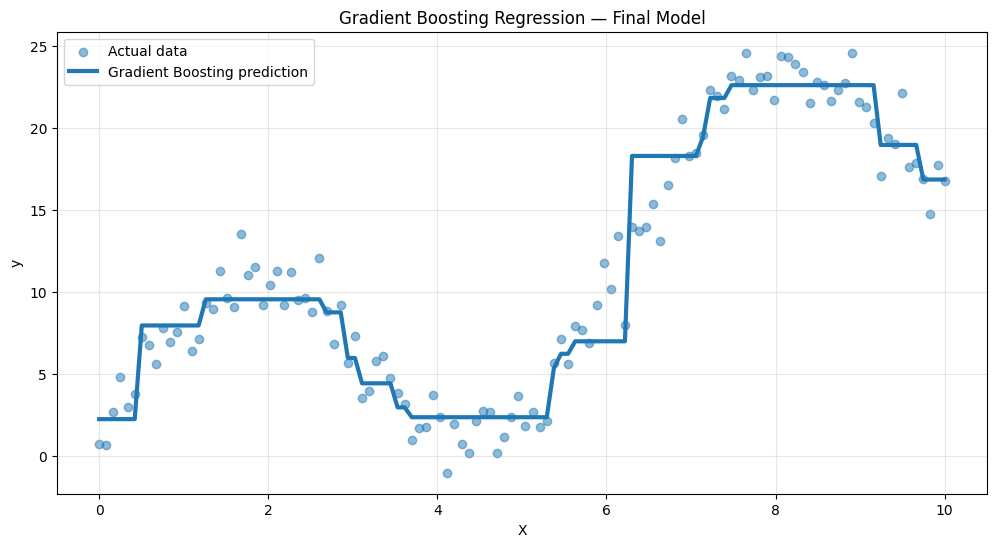

In [ ]:
# Sort X for a smooth prediction curve
sort_idx = np.argsort(X.ravel())

X_sorted = X[sort_idx]
y_sorted = y[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(12, 6))

plt.scatter(
    X.ravel(),
    y,
    alpha=0.5,
    label="Actual data"
)

plt.plot(
    X_sorted.ravel(),
    y_pred_sorted,
    linewidth=3,
    label="Gradient Boosting prediction"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Boosting Regression — Final Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 9. Plot model improvement at different stages

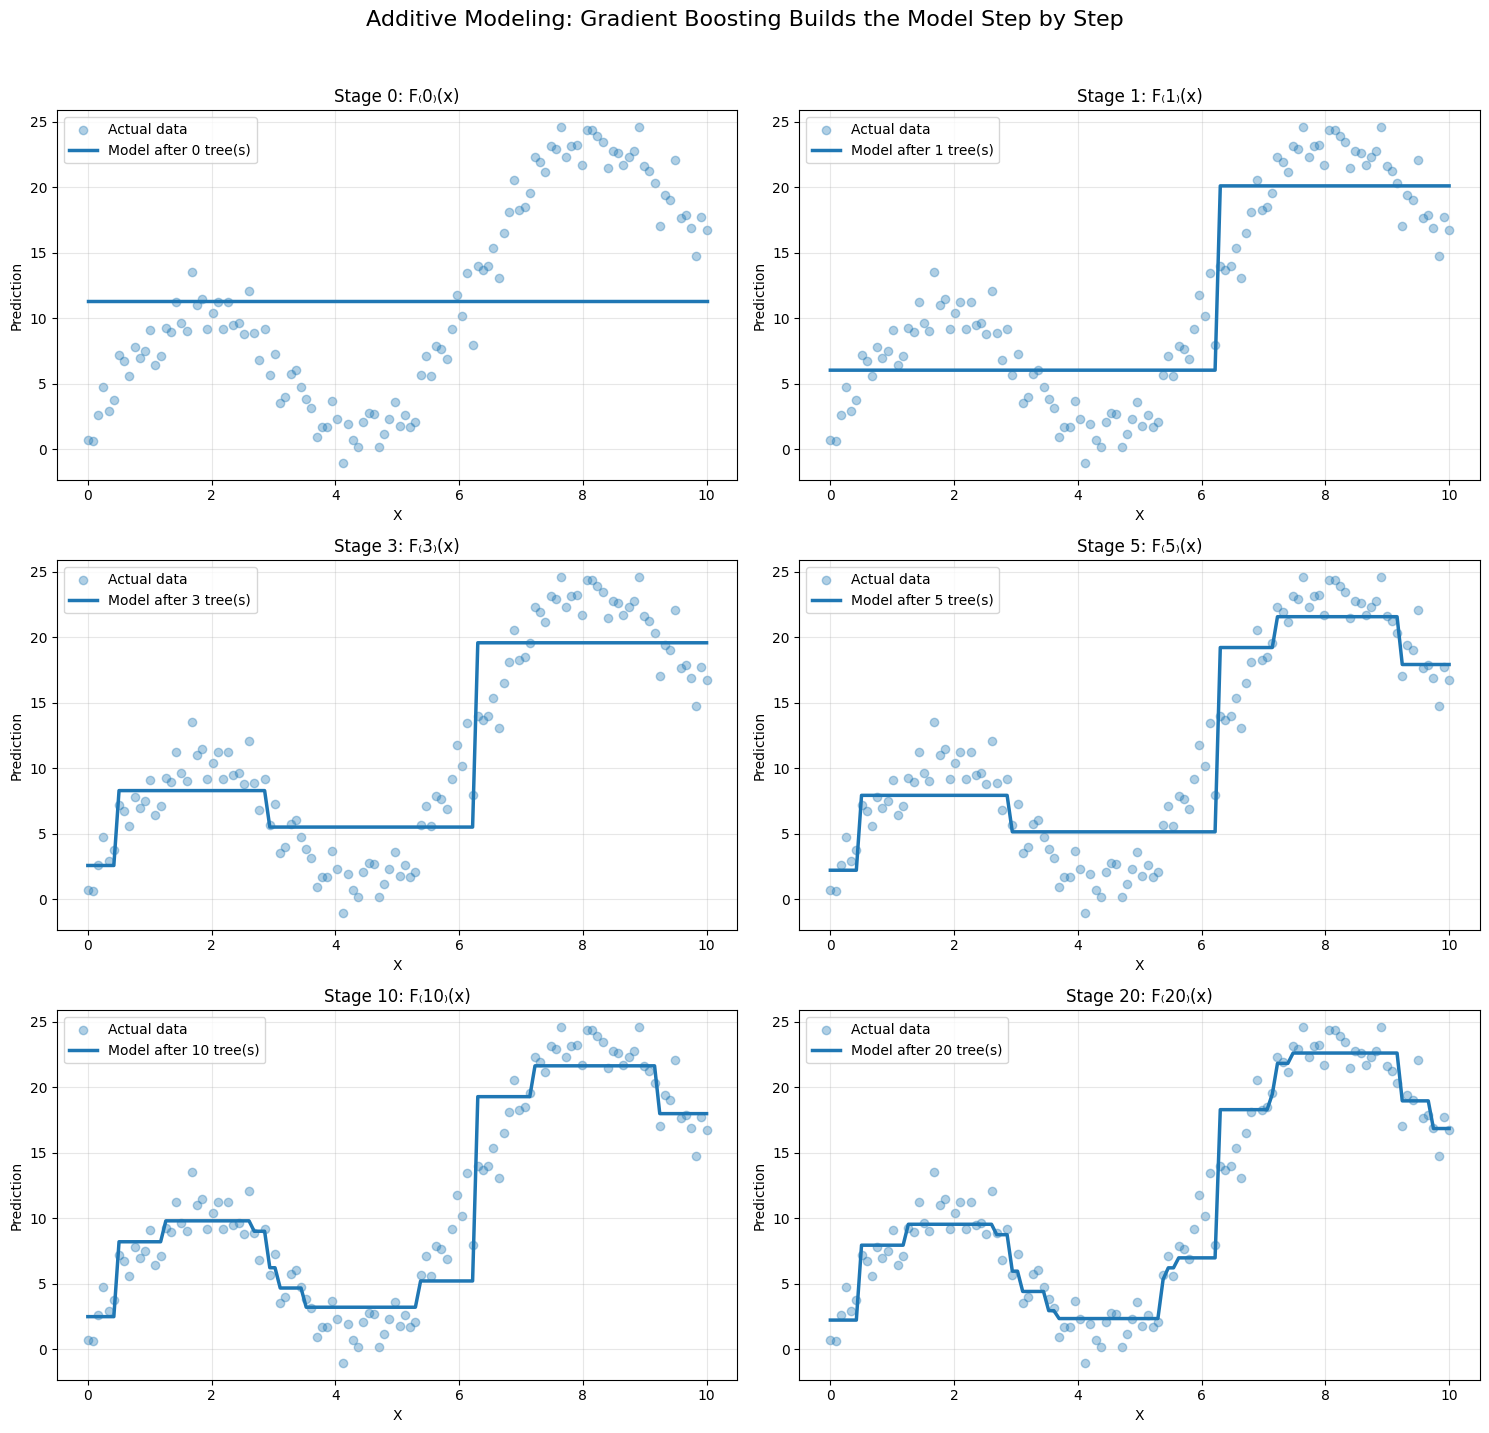

In [ ]:
stages_to_plot = [0, 1, 3, 5, 10, 20]

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 14)
)

axes = axes.ravel()

for ax, stage in zip(axes, stages_to_plot):

    stage_pred = gb_model.stage_predictions[stage]

    # Sort predictions for smooth line
    stage_pred_sorted = stage_pred[sort_idx]

    ax.scatter(
        X.ravel(),
        y,
        alpha=0.35,
        label="Actual data"
    )

    ax.plot(
        X_sorted.ravel(),
        stage_pred_sorted,
        linewidth=2.5,
        label=f"Model after {stage} tree(s)"
    )

    ax.set_title(f"Stage {stage}: F₍{stage}₎(x)")
    ax.set_xlabel("X")
    ax.set_ylabel("Prediction")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    "Additive Modeling: Gradient Boosting Builds the Model Step by Step",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# 10. Plot individual tree contributions

In [ ]:
# Calculate contribution of each tree on training data
tree_contributions = []

for m in range(1, len(gb_model.stage_predictions)):

    previous_prediction = gb_model.stage_predictions[m - 1]
    current_prediction = gb_model.stage_predictions[m]

    contribution = current_prediction - previous_prediction

    tree_contributions.append(contribution)

tree_contributions = np.array(tree_contributions)

print("Contribution matrix shape:", tree_contributions.shape)

Contribution matrix shape: (20, 120)


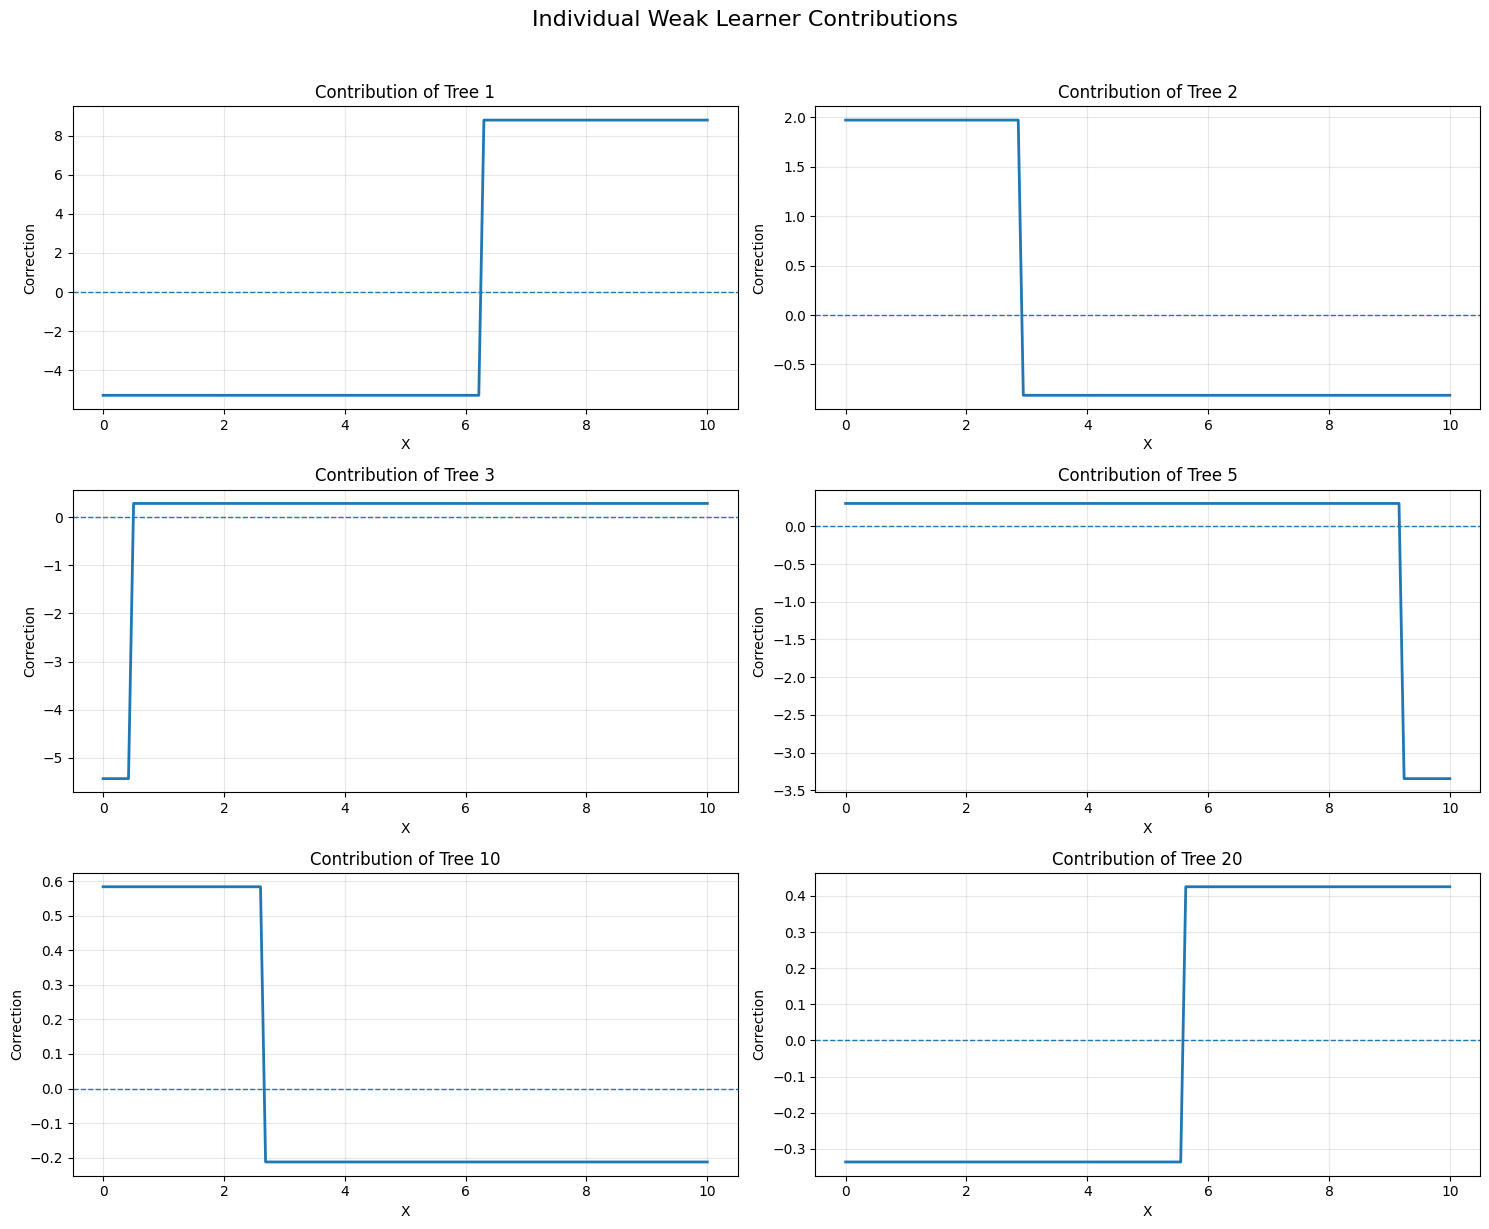

In [ ]:
trees_to_plot = [0, 1, 2, 4, 9, 19]

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 12)
)

axes = axes.ravel()

for ax, tree_idx in zip(axes, trees_to_plot):

    contribution = tree_contributions[tree_idx]
    contribution_sorted = contribution[sort_idx]

    ax.plot(
        X_sorted.ravel(),
        contribution_sorted,
        linewidth=2
    )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(
        f"Contribution of Tree {tree_idx + 1}"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Correction")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Individual Weak Learner Contributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# 11. Visualize residual reduction

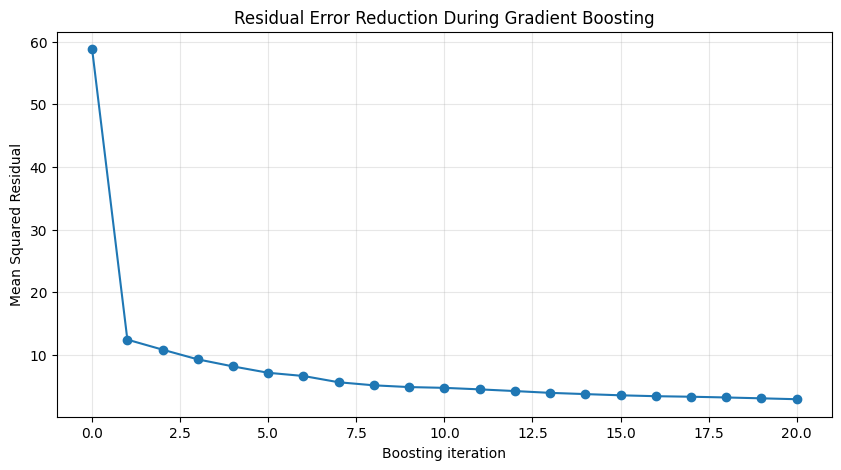

In [ ]:
residual_mse = []

for stage_pred in gb_model.stage_predictions:

    residual = y - stage_pred

    mse_stage = np.mean(residual ** 2)

    residual_mse.append(mse_stage)

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(residual_mse)),
    residual_mse,
    marker="o"
)

plt.xlabel("Boosting iteration")
plt.ylabel("Mean Squared Residual")
plt.title("Residual Error Reduction During Gradient Boosting")
plt.grid(alpha=0.3)

plt.show()

# 12. See the actual residuals at one iteration

In [ ]:
# Initial predictions
initial_predictions = gb_model.stage_predictions[0]

# Residuals for first iteration
first_residuals = y - initial_predictions

residual_df = pd.DataFrame({
    "X": X.ravel(),
    "Actual y": y,
    "Initial Prediction": initial_predictions,
    "Residual": first_residuals
})

residual_df.head(10)

,X,Actual y,Initial Prediction,Residual
0,0.000000,0.745071,11.32125,-10.576179
1,0.084034,0.632149,11.32125,-10.689102
2,0.168067,2.645884,11.32125,-8.675366
3,0.252101,4.784258,11.32125,-6.536992
4,0.336134,2.959762,11.32125,-8.361489
5,0.420168,3.752442,11.32125,-7.568808
6,0.504202,7.242092,11.32125,-4.079159
7,0.588235,6.766773,11.32125,-4.554477
8,0.672269,5.622429,11.32125,-5.698822
9,0.756303,7.816339,11.32125,-3.504912


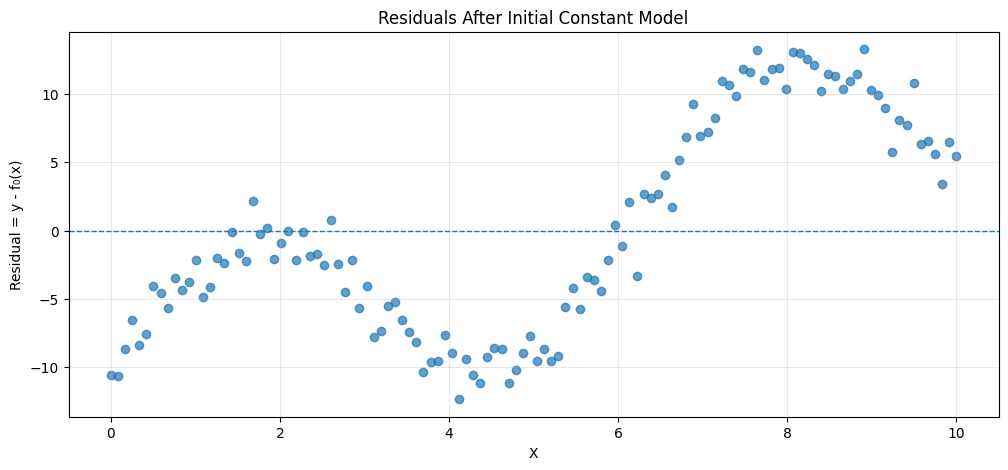

In [ ]:
plt.figure(figsize=(12, 5))

plt.scatter(
    X.ravel(),
    first_residuals,
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("X")
plt.ylabel("Residual = y - f₀(x)")
plt.title("Residuals After Initial Constant Model")
plt.grid(alpha=0.3)

plt.show()

# 13. Verify the γ calculation manually

In [ ]:
# First tree
first_tree = gb_model.trees[0]
first_gamma = gb_model.gammas[0]

# Leaf assignment
leaf_ids = first_tree.apply(X)

gamma_df = pd.DataFrame({
    "X": X.ravel(),
    "Residual": first_residuals,
    "Leaf_ID": leaf_ids
})

gamma_summary = (
    gamma_df
    .groupby("Leaf_ID")["Residual"]
    .agg(["count", "mean", "sum"])
    .reset_index()
)

gamma_summary

,Leaf_ID,count,mean,sum
0,1,75,-5.275984,-395.698801
1,2,45,8.793307,395.698801


In [ ]:
print("Stored gamma values:")

for leaf_id, gamma in first_gamma.items():
    print(f"Leaf {leaf_id}: {gamma:.4f}")

Stored gamma values:
Leaf 1: -5.2760
Leaf 2: 8.7933


# 16. A subtle but important point about learning rate

In [ ]:
# current_prediction = current_prediction + learning_rate * tree_contribution